https://arxiv.org/pdf/1608.01471

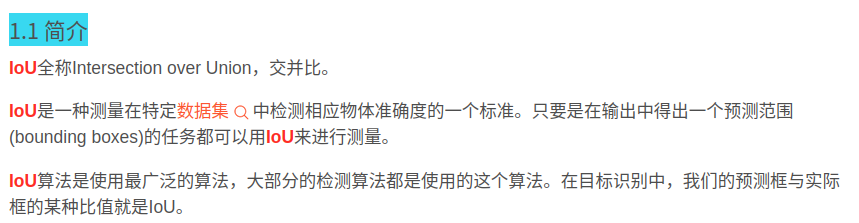

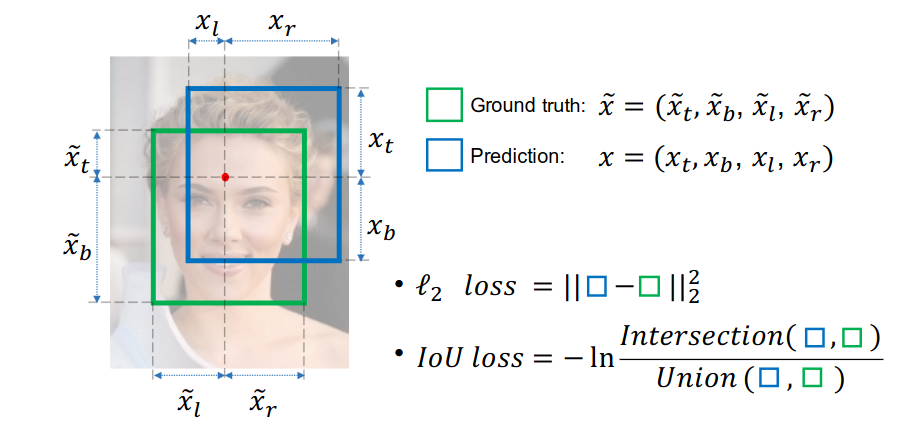

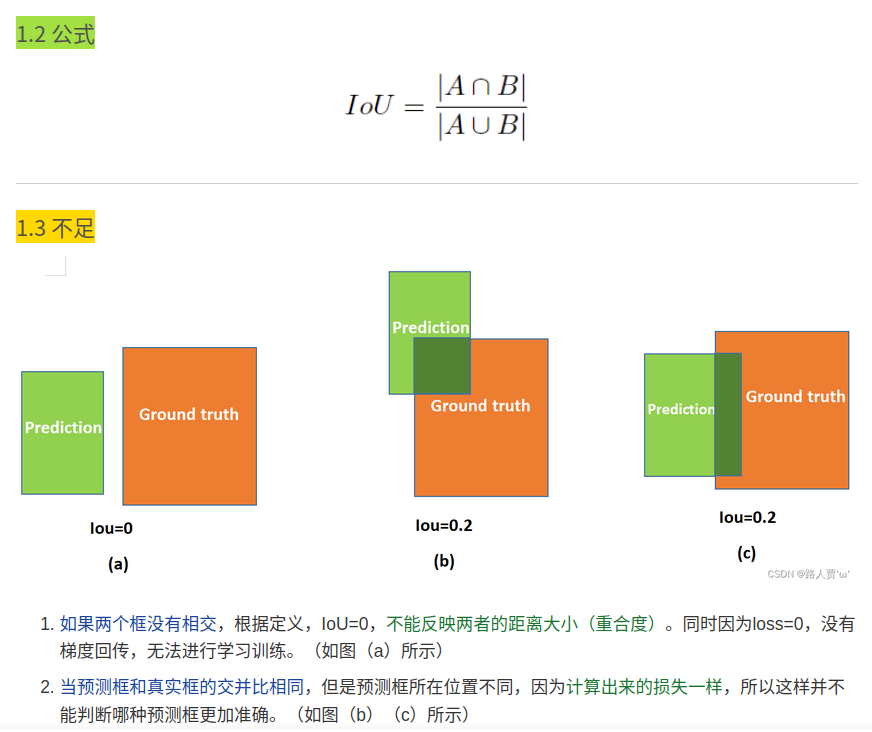

In [ ]:
import torch

def box_area(boxes):
    """ boxes: [N, 4] (x1, y1, x2, y2) """
    return (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])


def iou_loss(pred_boxes, target_boxes, eps=1e-7, reduction='mean'):
    # pred_boxes, target_boxes: [N, 4]
    # ---------- 交集 ----------
    inter_x1 = torch.max(pred_boxes[:, 0], target_boxes[:, 0])
    inter_y1 = torch.max(pred_boxes[:, 1], target_boxes[:, 1])
    inter_x2 = torch.min(pred_boxes[:, 2], target_boxes[:, 2])
    inter_y2 = torch.min(pred_boxes[:, 3], target_boxes[:, 3])
    
    inter_w = torch.clamp(inter_x2 - inter_x1, min=0)
    inter_h = torch.clamp(inter_y2 - inter_y1, min=0)
    inter_area = inter_w * inter_h
    
    # ---------- 并集 ----------
    pred_area = box_area(pred_boxes)
    target_area = box_area(target_boxes)
    union_area = pred_area + target_area - inter_area + eps
    
    iou = inter_area / union_area
    loss = 1.0 - iou
    
    if reduction == 'mean':
        return loss.mean()
    else:  # 'sum' or 'none'
        return loss.sum()